# 0.1 Import Libraries

In [3]:
import torch
import torch.nn as nn
from complex.complex_layers import ComplexConv2d, ComplexLinear, ComplexConvTranspose2d
from complex.complex_module import NativeComplexReLU
from tqdm.auto import tqdm
from stablediff.dataset import from_path_split
from stablediff.params import params_simple

In [4]:
N = params_simple['sample_rate']
FLATTENED_FEATURES = FLATTENED_FEATURES = 8160
EPS = 1e-8

# 1.0 Complex Encoder

In [34]:
class ComplexEncoder(nn.Module):
    def __init__(self, latent_dim):
        super(ComplexEncoder, self).__init__()

        # Convolutional feature extractor. Channels shrink while the spatial size
        # is progressively halved by the stride-2 kernels (see shape table above).
        self.conv1 = ComplexConv2d(in_channels=1, out_channels=512, kernel_size=(5, 1), stride=(2, 1))
        self.conv2 = ComplexConv2d(in_channels=512, out_channels=256, kernel_size=(3, 1), stride=(2, 1))
        self.conv3 = ComplexConv2d(in_channels=256, out_channels=128, kernel_size=(3, 1), stride=(2, 1))
        self.conv4 = ComplexConv2d(in_channels=128, out_channels=64, kernel_size=(2, 1), stride=(2, 1))
        self.conv5 = ComplexConv2d(in_channels=64, out_channels=32, kernel_size=(1, 1), stride=(1, 1))
        self.relu = NativeComplexReLU()

        # Parameters of the complex-normal posterior q(z|x):
        #   mu    - complex mean,
        #   sigma - real covariance (made real & positive in ``forward``),
        #   delta - complex pseudo-covariance.
        self.mu = ComplexLinear(FLATTENED_FEATURES, latent_dim)
        self.sigma = ComplexLinear(FLATTENED_FEATURES, latent_dim)
        self.delta = ComplexLinear(FLATTENED_FEATURES, latent_dim)

        # KL divergence of the most recent forward pass (filled in by ``forward``).
        self.kl = 0.0

    def compute_reparam_trick(self, mu, sigma, delta):
        """Differentiably sample ``z`` from ``CN(mu, sigma, delta)`` (Eqs. 16-18).

        A complex latent is built from two *independent real* standard-normal
        draws ``eps_r, eps_i`` so that gradients can flow back through ``mu``,
        ``sigma`` and ``delta``:

            z = mu + k_r * eps_r + k_i * eps_i

        with ``k_r = (sigma + delta) / sqrt(2*sigma + 2*Re(delta))`` and
        ``k_i = i * sqrt(sigma^2 - |delta|^2) / sqrt(2*sigma + 2*Re(delta))``.
        This is a Cholesky-style factorisation of the 2x2 real covariance of the
        complex variable. Because we constrain ``|delta| < sigma`` in ``forward``,
        both radicands are strictly positive; the signed-square-root helpers below
        therefore act only as a defensive guard against numerical noise.
        """
        numerator = sigma ** 2 - torch.abs(delta) ** 2   # sigma^2 - |delta|^2  (> 0 by construction)
        denominator = 2 * sigma + 2 * torch.real(delta)  # 2*sigma + 2*Re(delta) (> 0 by construction)

        # Signed square root: keep a real root for non-negative inputs and rotate
        # negative inputs onto the imaginary axis, so ``sqrt`` never sees a
        # negative real value. The mapping converts sign -1 -> -1j and +1 -> +1.
        numerator_sign = torch.sign(numerator.detach())
        denominator_sign = torch.sign(denominator.detach())
        numerator_sign = (numerator_sign - 1) / 2 * -1j + ((numerator_sign + 1) / 2)
        denominator_sign = (denominator_sign - 1) / 2 * -1j + ((denominator_sign + 1) / 2)
        numerator = numerator_sign * torch.sqrt(torch.abs(numerator))
        denominator = denominator_sign * torch.sqrt(torch.abs(denominator)) + EPS

        kx = (sigma + delta) / denominator       # k_r, Eq. (17)
        ky = 1j * numerator / denominator         # k_i, Eq. (18)

        # Two independent real standard-normal tensors, created on the same device
        # as the parameters so the model runs on CPU or GPU without any hard-coded
        # device. (The original code forced these onto CUDA, breaking CPU runs.)
        epsilon_r = torch.randn(mu.shape, device=mu.device)
        epsilon_i = torch.randn(mu.shape, device=mu.device)

        z = mu + kx * epsilon_r + ky * epsilon_i  # Eq. (16)
        return z

    def compute_complex_kl(self, mu, sigma, delta):
        """KL divergence between q(z|x) and the prior CN(0, I, 0) (Eq. 15).

        ``KL = ||mu||^2 + || sigma - 1 - 0.5 * log(sigma^2 - |delta|^2) ||_1``

        The mean term ``||mu||^2`` is the squared magnitude of the posterior mean.
        The second term is an L1 norm (a *per-dimension absolute value*, summed),
        exactly as published; this is why ``torch.abs`` wraps the whole bracket.
        The result is stored per sample in ``self.kl`` (shape ``(B,)``).
        """
        # log-determinant-like quantity; strictly positive because |delta| < sigma.
        log_det = torch.log(torch.clamp(sigma ** 2 - torch.abs(delta) ** 2, min=EPS))
        mean_term = torch.real((torch.conj(mu) * mu).sum(dim=1))            # ||mu||^2
        variance_term = torch.abs(sigma - 1 - log_det / 2).sum(dim=1)       # L1 norm
        self.kl = mean_term + variance_term

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.relu(self.conv5(x))
        x = torch.flatten(x, start_dim=1)

        mu = self.mu(x)
        # sigma must be real and positive; exp(.) of the real part guarantees both.
        sigma = torch.exp(torch.real(self.sigma(x)))

        # Pseudo-covariance, constrained to |delta| < sigma so the complex-normal
        # covariance stays valid (sigma^2 - |delta|^2 > 0). We express delta as
        # ``sigma * rho`` with a complex correlation coefficient ``rho`` of
        # magnitude tanh(|delta_raw|) < 1, keeping the phase of the raw output.
        delta_raw = self.delta(x)
        delta_mag = torch.abs(delta_raw)
        rho = delta_raw / (delta_mag + EPS) * torch.tanh(delta_mag)
        delta = sigma * rho

        z = self.compute_reparam_trick(mu, sigma, delta)
        self.compute_complex_kl(mu, sigma, delta)
        return z


# 1.1 Complex Decoder

In [35]:
class ComplexDecoder(nn.Module):
    """Complex-valued transposed-convolutional decoder.

    Mirrors the encoder: maps a complex latent ``(B, latent_dim)`` back to a
    reconstructed complex spectrogram patch ``(B, 1, 512, 64)``.
    """

    def __init__(self, latent_dims):
        super().__init__()

        self.lim_linear1 = ComplexLinear(latent_dims, 128)
        self.lim_linear2 = ComplexLinear(128, FLATTENED_FEATURES)

        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 255, 1))

        # ``output_padding`` is tuned so each transposed convolution exactly
        # inverts the spatial size of its encoder counterpart (see shape table).
        self.dec1 = ComplexConvTranspose2d(in_channels=32, out_channels=64, kernel_size=(1, 1), stride=(1, 1))
        self.dec2 = ComplexConvTranspose2d(in_channels=64, out_channels=128, kernel_size=(2, 1), stride=(2, 1))
        self.dec3 = ComplexConvTranspose2d(in_channels=128, out_channels=256, kernel_size=(3, 1), stride=(2, 1),
                                           output_padding=(1, 0))
        self.dec4 = ComplexConvTranspose2d(in_channels=256, out_channels=512, kernel_size=(3, 1), stride=(2, 1),
                                           output_padding=(1, 0))
        self.dec5 = ComplexConvTranspose2d(in_channels=512, out_channels=1, kernel_size=(5, 1), stride=(2, 1),
                                           output_padding=(1, 0))
        self.relu = NativeComplexReLU()

    def forward(self, x):
        x = self.relu(self.lim_linear1(x))
        x = self.relu(self.lim_linear2(x))
        x = self.unflatten(x)
        x = self.relu(self.dec1(x))
        x = self.relu(self.dec2(x))
        x = self.relu(self.dec3(x))
        x = self.relu(self.dec4(x))
        x = self.dec5(x)
        return x

In [36]:
class CVAE(nn.Module):
    """End-to-end complex-valued VAE: ``x_hat = Decoder(Encoder(x))``.

    After a forward pass, the per-sample KL divergence is available as
    ``model.encoder.kl`` for the training objective.
    """

    def __init__(self, latent_dims):
        super(CVAE, self).__init__()
        self.encoder = ComplexEncoder(latent_dims)
        self.decoder = ComplexDecoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# 2.0 Training

In [41]:
# Use single-precision (complex64) and a fixed seed for reproducibility.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device}")
torch.set_default_dtype(torch.float32)
torch.manual_seed(0)

# Default hyper-parameters (overridable via the CLI or the ``main`` arguments).
LR = 1e-4
NUM_EPOCHS = 5
LATENT_DIMS = 250
BATCH_SIZE = 8
WEIGHT_DECAY = 1e-5

Selected device: cpu


In [42]:
def train_epoch(vae, device, dataloader, optimizer):
    """Run one training epoch and return per-sample loss, reconstruction error, KL."""

    vae.train()

    train_loss = 0.0
    reconstruction_error_epoch = 0.0
    kl_error_epoch = 0.0

    for batch in tqdm(dataloader):

        x = batch["data"].to(device)

        optimizer.zero_grad()

        x_hat = vae(x)

        reconstruction_error = (
            torch.abs(x - x_hat) ** 2
        ).mean()

        # KL computed by encoder during forward pass
        kl_error = vae.encoder.kl.mean()

        loss = reconstruction_error + kl_error

        loss.backward()
        optimizer.step()

        reconstruction_error_epoch += reconstruction_error.item()
        kl_error_epoch += kl_error.item()
        train_loss += loss.item()

    len_dataset = len(dataloader.dataset)

    return (
        train_loss / len_dataset,
        reconstruction_error_epoch / len_dataset,
        kl_error_epoch / len_dataset
    )

def test_epoch(vae, device, dataloader):
    """Run one validation epoch and return per-sample loss."""

    vae.eval()

    val_loss = 0.0

    with torch.no_grad():

        for batch in dataloader:

            x = batch["data"].to(device)

            x_hat = vae(x)

            reconstruction_error = (
                torch.abs(x - x_hat) ** 2
            ).mean()

            kl_error = vae.encoder.kl.mean()

            loss = reconstruction_error + kl_error

            val_loss += loss.item()

    return val_loss / len(dataloader.dataset)


100%|██████████| 960/960 [17:30<00:00,  1.09s/it]



 EPOCH 1/5 	 train loss 1.016 (recon error 1.003, kl error 0.012) 	 val loss 1.001


100%|██████████| 960/960 [19:16<00:00,  1.20s/it]



 EPOCH 2/5 	 train loss 1.001 (recon error 1.001, kl error 0.000) 	 val loss 1.001


100%|██████████| 960/960 [30:14<00:00,  1.89s/it]


...

100%|██████████| 960/960 [22:35<00:00,  1.41s/it]



 EPOCH 4/5 	 train loss 1.000 (recon error 1.000, kl error 0.000) 	 val loss 1.001


100%|██████████| 960/960 [12:54<00:00,  1.24it/s]



 EPOCH 5/5 	 train loss 1.000 (recon error 1.000, kl error 0.000) 	 val loss 1.000


ValueError: maxlags must be None or strictly positive < 5

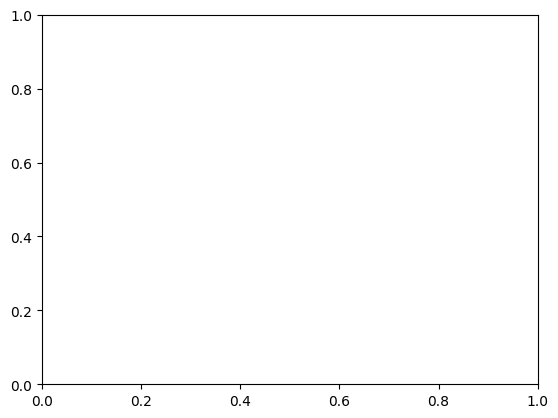

In [ ]:
vae = CVAE(latent_dims=LATENT_DIMS).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_loader, valid_loader = from_path_split(params_simple)

history = {"train_loss": [], "reconstruction_error": [], "kl_error": [], "val_loss": []}
for epoch in range(NUM_EPOCHS):
    train_loss, reconstruction_error, kl_error = train_epoch(vae, device, train_loader, optimizer)
    val_loss = test_epoch(vae, device, valid_loader)

    history["train_loss"].append(train_loss)
    history["reconstruction_error"].append(reconstruction_error)
    history["kl_error"].append(kl_error)
    history["val_loss"].append(val_loss)

    print('\n EPOCH {}/{} \t train loss {:.3f} (recon error {:.3f}, kl error {:.3f}) \t val loss {:.3f}'.format(
        epoch + 1, NUM_EPOCHS, train_loss, reconstruction_error, kl_error, val_loss))